# 📊 Multi-Asset Time Series EDA Step-by-Step Notebook

## ✅ EDA for multi-asset time series  
- Risk metrics (Vol, VaR/ES, MaxDD, Calmar, Sharpe)  
- Calendar-year returns  
- Time-series characteristics (autocorrs, volatility clustering, optional ADF)  
- Static and rolling correlations  
- Extreme events & VIX extremes  
- Tail summary & same-day contagion events

In [1]:
CSV_PATH = 'timeseries_data.csv'   
DATE_COL = '날짜'                  
TARGET   = 'KOSPI'                 
DROP_COLS = ['Silver','Copper','USD/GBP','USD/CNY','USD/JPY','USD/EUR','USD/CAD']  # removed if exist

ROLL_WINDOWS = [63, 126, 252]
MIN_PERIODS = 60

TOP_EXTREMES = 40
EXTREME_P_LO = 0.01
EXTREME_P_HI = 0.99

CONTAGION_SIGMA = 2.0

In [2]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from statsmodels.tsa.stattools import adfuller
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

try:
    from ace_tools import display_dataframe_to_user as _display_df
    def show_df(name, df): 
        _display_df(name, df)
except Exception:
    def show_df(name, df):
        display(df)

%matplotlib inline

In [3]:
def load_csv(path, date_col):
    df = pd.read_csv(path, index_col=date_col, parse_dates=True)
    df = df.sort_index()
    df = df.dropna(axis=1, how='all')
    return df

def maybe_drop_columns(df, cols):
    cols = list(dict.fromkeys(cols))
    keep = [c for c in df.columns if c not in cols]
    return df[keep]

def to_returns_pct(df):
    return df.pct_change().mul(100.0).dropna(how='all')

def annual_returns_from_daily_pct(series):
    s = series.dropna()
    return s.groupby(s.index.year).apply(lambda r: (1 + r/100.0).prod() - 1).mul(100.0)

def hist_var_es(returns_pct, q=0.01):
    r = pd.Series(returns_pct).dropna().values
    if len(r)==0:
        return np.nan, np.nan
    var = -np.quantile(r, q)
    es  = -r[r <= np.quantile(r, q)].mean() if np.any(r <= np.quantile(r, q)) else np.nan
    return float(var), float(es)

def max_drawdown_from_returns(returns_pct):
    curve = (1 + returns_pct/100.0).cumprod()
    dd = (curve / curve.cummax()) - 1.0
    return float(dd.min() * 100.0)

def calmar_from_returns(returns_pct):
    r = pd.Series(returns_pct).dropna()
    if r.empty:
        return np.nan
    ann = r.mean() * 252.0
    mdd = max_drawdown_from_returns(r) / 100.0
    if mdd == 0:
        return np.nan
    return float(ann / abs(mdd))

def sharpe_from_returns(returns_pct, risk_free_annual=0.0):
    r = pd.Series(returns_pct).dropna()
    if r.std() == 0 or r.empty:
        return np.nan
    excess_daily = r - (risk_free_annual / 252.0)
    return float((excess_daily.mean() * 252.0) / (excess_daily.std() * math.sqrt(252.0)))


In [4]:
# === Load data ===
df = load_csv(CSV_PATH, DATE_COL)
df = maybe_drop_columns(df, DROP_COLS)
print(f"Loaded shape: {df.shape}")
print(f"Date range: {df.index.min().date()} ~ {df.index.max().date()}")
print("Columns:", list(df.columns))
show_df("Raw (head)", df.head())

Loaded shape: (5949, 17)
Date range: 2004-01-01 ~ 2022-12-31
Columns: ['S&P', 'DJAI', 'Nasdaq', 'VIX', 'KOSDAQ', 'FTSE', 'Nikkei', 'DAX', 'CAC', 'SHCOMP', 'KOSPI', 'USD/KRW', 'US 10Y', 'Gold', 'Crude', 'Brent', 'Gas']


,S&P,DJAI,Nasdaq,VIX,KOSDAQ,FTSE,Nikkei,DAX,CAC,SHCOMP,KOSPI,USD/KRW,US 10Y,Gold,Crude,Brent,Gas
날짜,,,,,,,,,,,,,,,,,
2004-01-01,1108.479980,10409.849609,2006.680054,18.219999,451.399994,4510.200195,10825.169922,4018.500000,3596.800049,1517.192993,821.260010,1181.599976,4.373,424.399994,33.779999,75.739998,6.827
2004-01-02,1108.479980,10409.849609,2006.680054,18.219999,451.399994,4510.200195,10825.169922,4018.500000,3596.800049,1517.192993,821.260010,1195.800049,4.373,424.399994,33.779999,75.739998,6.827
2004-01-03,1108.479980,10409.849609,2006.680054,18.219999,451.399994,4510.200195,10825.169922,4018.500000,3596.800049,1517.192993,821.260010,1195.800049,4.373,424.399994,33.779999,75.739998,6.827
2004-01-05,1108.479980,10409.849609,2006.680054,18.219999,452.700012,4510.200195,10825.169922,4018.500000,3596.800049,1568.353027,824.099976,1178.900024,4.373,424.399994,33.779999,75.739998,6.827
2004-01-06,1122.219971,10544.070312,2047.359985,17.490000,447.299988,4513.299805,10813.990234,4035.899902,3608.290039,1574.522949,823.429993,1189.400024,4.387,422.799988,33.700001,75.739998,7.082


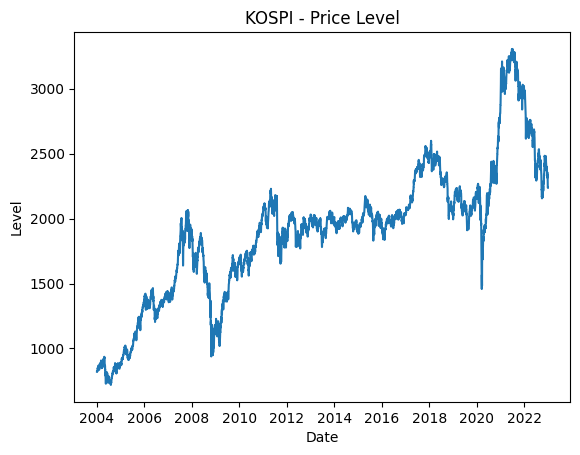

In [5]:
# === Plot: Target price level ===
if TARGET in df.columns:
    plt.figure()
    plt.plot(df.index, df[TARGET].values)
    plt.title(f"{TARGET} - Price Level")
    plt.xlabel("Date")
    plt.ylabel("Level")
    plt.show()
else:
    print(f"TARGET '{TARGET}' not in columns.")

In [6]:
# === Returns computation (all assets, %) ===
ret = to_returns_pct(df)
show_df("Returns (head)", ret.head())

desc = ret.describe().T
desc = desc.rename(columns={'mean':'mean_%','std':'std_%'})
show_df("Returns descriptive", desc)

,S&P,DJAI,Nasdaq,VIX,KOSDAQ,FTSE,Nikkei,DAX,CAC,SHCOMP,KOSPI,USD/KRW,US 10Y,Gold,Crude,Brent,Gas
날짜,,,,,,,,,,,,,,,,,
2004-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.201767,0.000000,0.000000,0.000000,0.0,0.000000
2004-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2004-01-05,0.000000,0.000000,0.000000,0.000000,0.287997,0.000000,0.000000,0.000000,0.000000,3.372019,0.345806,-1.413282,0.000000,0.000000,0.000000,0.0,0.000000
2004-01-06,1.239534,1.289363,2.027226,-4.006584,-1.192848,0.068724,-0.103275,0.432995,0.319450,0.393401,-0.081299,0.890661,0.320145,-0.377004,-0.236821,0.0,3.735164
2004-01-07,0.129215,-0.051310,0.488929,-4.345342,-0.268272,-0.179461,-0.519419,-0.011397,-0.345592,0.805389,0.442055,-1.059356,-2.507411,-0.212865,-0.237394,0.0,-2.880542


,count,mean_%,std_%,min,25%,50%,75%,max
S&P,5948.0,0.026901,1.095079,-11.984055,-0.262653,0.0,0.409591,11.580037
DJAI,5948.0,0.024889,1.039615,-12.926546,-0.263226,0.0,0.395063,11.365041
Nasdaq,5948.0,0.035320,1.227119,-12.321331,-0.336863,0.0,0.530425,11.805930
VIX,5948.0,0.231781,7.028699,-29.572651,-3.130481,0.0,2.280060,115.597925
KOSDAQ,5948.0,0.015409,1.300629,-11.705901,-0.384419,0.0,0.616008,11.468802
FTSE,5948.0,0.013565,1.011268,-10.873819,-0.342547,0.0,0.410673,9.838667
Nikkei,5948.0,0.022881,1.270056,-11.406368,-0.406649,0.0,0.527343,14.150312
DAX,5948.0,0.028107,1.200693,-12.238615,-0.368980,0.0,0.518361,11.401954
CAC,5948.0,0.017250,1.213236,-12.276774,-0.417680,0.0,0.519022,11.176173
SHCOMP,5948.0,0.021122,1.351111,-8.840630,-0.399726,0.0,0.499086,9.455139


In [7]:
# === Risk metrics per asset ===
risk_rows = []
for col in ret.columns:
    r = ret[col].dropna()
    if r.empty:
        continue
    var99, es99 = hist_var_es(r, q=0.01)
    var95, es95 = hist_var_es(r, q=0.05)
    row = {
        'Asset': col,
        'Mean_%': r.mean(),
        'Std_%': r.std(),
        'Ann_Vol_%': r.std() * math.sqrt(252.0),
        'Skew': (r.skew() if HAS_SCIPY else np.nan),
        'Kurtosis_Excess': (r.kurtosis() if HAS_SCIPY else np.nan),
        'VaR_99(%)': var99, 'ES_99(%)': es99,
        'VaR_95(%)': var95, 'ES_95(%)': es95,
        'MaxDD_%': max_drawdown_from_returns(r),
        'Calmar': calmar_from_returns(r),
        'Sharpe': sharpe_from_returns(r),
    }
    if HAS_SCIPY:
        jb = stats.jarque_bera(r)
        row['JB_stat'] = float(jb.statistic)
        row['JB_p'] = float(jb.pvalue)
    risk_rows.append(row)

risk = pd.DataFrame(risk_rows).set_index('Asset').sort_index()
show_df("Risk metrics", risk.round(4))


,Mean_%,Std_%,Ann_Vol_%,Skew,Kurtosis_Excess,VaR_99(%),ES_99(%),VaR_95(%),ES_95(%),MaxDD_%,Calmar,Sharpe,JB_stat,JB_p
Asset,,,,,,,,,,,,,,
Brent,0.0213,1.9489,30.9385,-0.3222,17.7339,6.0072,8.3780,2.9624,4.8823,-86.7675,6.1748,0.1732,7.790440e+04,0.0
CAC,0.0172,1.2132,19.2595,-0.0627,10.9839,3.6342,4.9864,1.8746,2.9910,-59.1565,7.3481,0.2257,2.984853e+04,0.0
Crude,-0.0195,4.9206,78.1114,-43.1643,2588.1695,6.5205,16.1600,3.4736,6.8170,-125.8999,-3.8977,-0.0628,1.659197e+09,0.0
DAX,0.0281,1.2007,19.0604,-0.0063,10.8985,3.4555,4.8597,1.8803,2.9345,-54.7675,12.9327,0.3716,2.938232e+04,0.0
DJAI,0.0249,1.0396,16.5034,-0.1666,20.2547,3.1089,4.6287,1.5145,2.5792,-53.7786,11.6626,0.3800,1.015208e+05,0.0
FTSE,0.0136,1.0113,16.0534,-0.2140,13.1996,3.0560,4.2825,1.5211,2.5217,-47.8329,7.1466,0.2129,4.314618e+04,0.0
Gas,0.0414,3.1425,49.8852,1.1631,15.1532,7.9635,10.4316,4.5833,6.7871,-90.3629,11.5479,0.2092,5.814458e+04,0.0
Gold,0.0296,1.0118,16.0615,-0.2274,7.2906,3.0228,3.9978,1.6367,2.4889,-44.3638,16.8161,0.4645,1.319833e+04,0.0
KOSDAQ,0.0154,1.3006,20.6469,-0.9942,10.1533,4.3187,6.1146,2.0760,3.5034,-68.4637,5.6717,0.1881,2.648024e+04,0.0


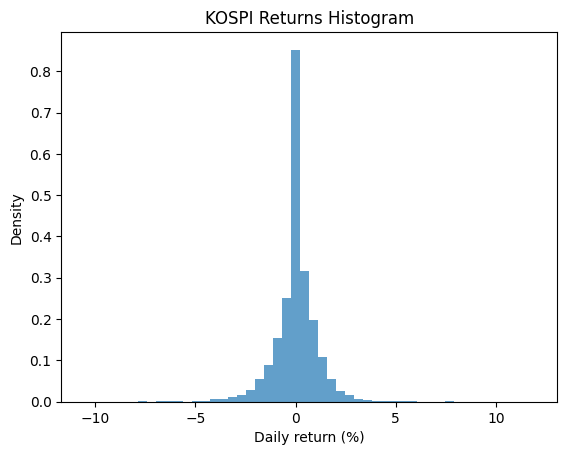

In [8]:
# === Plot: Histogram of TARGET returns ===
if TARGET in ret.columns:
    plt.figure()
    plt.hist(ret[TARGET].dropna().values, bins=50, density=True, alpha=0.7)
    plt.title(f"{TARGET} Returns Histogram")
    plt.xlabel("Daily return (%)")
    plt.ylabel("Density")
    plt.show()
else:
    print(f"TARGET '{TARGET}' not in returns.")


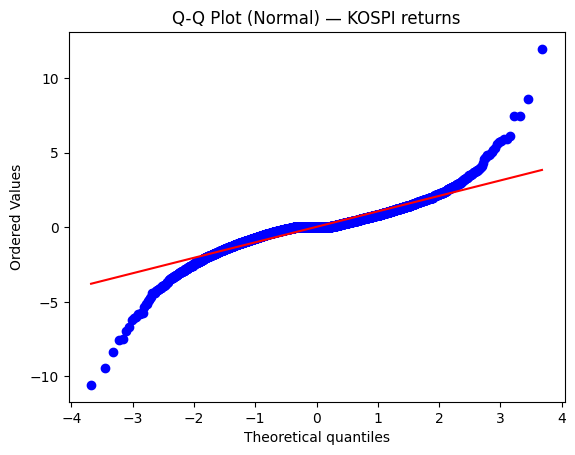

In [9]:
# === Plot: Q-Q plot vs normal (TARGET) ===
if TARGET in ret.columns and HAS_SCIPY:
    plt.figure()
    stats.probplot(ret[TARGET].dropna().values, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot (Normal) — {TARGET} returns")
    plt.show()
else:
    if TARGET in ret.columns:
        print("SciPy not available — skipping Q-Q plot.")
    else:
        print(f"TARGET '{TARGET}' not in returns.")


In [10]:
# === Calendar-year returns table ===
rows = []
for col in ret.columns:
    yr = annual_returns_from_daily_pct(ret[col])
    if not yr.empty:
        rows.append(yr.rename(col))
cal_tbl = pd.concat(rows, axis=1) if rows else pd.DataFrame()
show_df("Calendar-year returns (%)", cal_tbl)


,S&P,DJAI,Nasdaq,VIX,KOSDAQ,FTSE,Nikkei,DAX,CAC,SHCOMP,KOSPI,USD/KRW,US 10Y,Gold,Crude,Brent,Gas
날짜,,,,,,,,,,,,,,,,,
2004,9.478752,3.750777,8.554430,-31.064759,-15.744353,6.871090,6.130064,5.912158,6.426543,-16.523740,9.090906,-15.148951,-2.515439,3.086712,28.626413,0.000000,-9.931155
2005,2.862675,-0.766644,1.238557,-3.901280,84.521337,16.570189,40.236457,27.071382,23.178987,-8.325251,53.961294,-0.314179,3.096410,18.194280,40.483314,0.000000,82.550009
2006,13.619432,16.287851,9.521066,-4.225346,-13.628002,10.714032,6.916831,21.978607,17.528939,130.434346,3.993850,-8.255541,7.167237,22.838917,0.016380,0.000000,-43.884191
2007,4.243809,7.243110,10.730385,79.411756,16.180805,4.116836,-11.134731,22.289188,1.542655,96.659087,32.253953,1.027328,-13.036090,31.438918,57.215405,23.910749,18.796635
2008,-39.760159,-35.145340,-42.018203,100.723247,-52.849212,-32.178970,-42.123813,-40.374247,-42.829448,-65.394217,-40.727838,34.094733,-49.047857,5.833028,-53.531989,-51.422482,-24.869700
2009,26.473101,21.689382,47.757793,-52.053811,54.666474,22.883413,19.040234,23.849942,22.329534,79.982965,49.650063,-7.333761,81.312895,23.947485,77.937227,70.936609,-0.889367
2010,11.670599,9.680990,16.222371,-12.224443,-0.560781,10.617094,-3.010689,16.059941,-2.153220,-14.313156,21.882371,-2.084962,-10.967230,29.757126,15.146165,21.583472,-20.944002
2011,-0.022262,5.599532,-2.171630,33.561638,-2.058002,-6.677277,-17.338784,-14.692102,-17.943210,-21.675329,-10.982936,2.510873,-44.464230,10.182259,8.152774,13.329812,-32.145291
2012,11.516387,5.897665,13.633003,-2.905984,-0.771719,6.336703,22.942045,29.059652,14.571760,3.169519,9.383048,-10.152332,-8.551581,6.961298,-7.092990,3.473648,12.111073


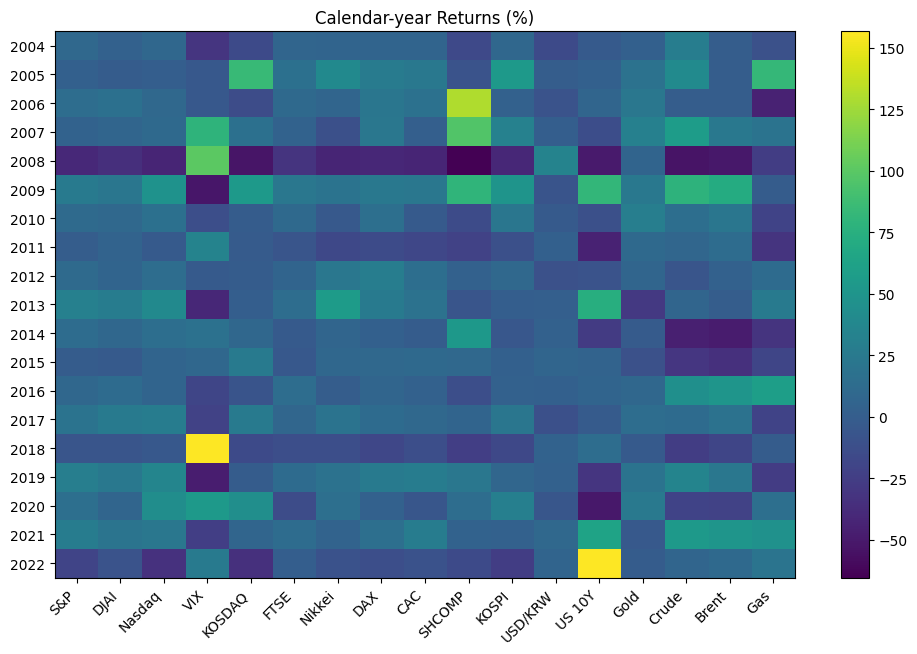

In [11]:
# === Plot: Calendar-year heatmap (imshow) ===
if not cal_tbl.empty:
    plt.figure(figsize=(10, max(4, 0.35*len(cal_tbl.index))))
    data = cal_tbl.fillna(0).values
    im = plt.imshow(data, aspect='auto')
    plt.yticks(range(len(cal_tbl.index)), cal_tbl.index)
    plt.xticks(range(len(cal_tbl.columns)), cal_tbl.columns, rotation=45, ha='right')
    plt.title("Calendar-year Returns (%)")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
else:
    print("No calendar-year table available.")


In [12]:
# === Time-series characteristics ===
rows = []
for col in ret.columns:
    r = ret[col].dropna()
    if r.empty: 
        continue
    row = {
        'Asset': col,
        'Autocorr_lag1': r.autocorr(lag=1),
        'Autocorr_lag5': r.autocorr(lag=5),
        'Autocorr_lag22': r.autocorr(lag=22),
        'VolClustering_lag1(|r|)': r.abs().autocorr(lag=1),
    }
    if HAS_STATSMODELS and col in df.columns:
        try:
            row['ADF_p_price'] = adfuller(df[col].dropna())[1]
        except Exception:
            row['ADF_p_price'] = np.nan
        try:
            row['ADF_p_returns'] = adfuller(r.dropna())[1]
        except Exception:
            row['ADF_p_returns'] = np.nan
    rows.append(row)

ts_char = pd.DataFrame(rows).set_index('Asset').sort_index()
show_df("TS characteristics", ts_char.round(4))


,Autocorr_lag1,Autocorr_lag5,Autocorr_lag22,VolClustering_lag1(|r|),ADF_p_price,ADF_p_returns
Asset,,,,,,
Brent,-0.0192,0.0447,-0.0063,0.2507,0.1169,0.0
CAC,-0.0213,0.0248,-0.0218,0.0908,0.4558,0.0
Crude,0.2351,0.0544,-0.0099,0.3579,0.0518,0.0
DAX,-0.0113,0.0108,-0.0287,0.0731,0.6610,0.0
DJAI,-0.1066,-0.0138,-0.0414,0.2234,0.9673,0.0
FTSE,-0.0290,0.0368,-0.0144,0.1566,0.1566,0.0
Gas,-0.0716,0.0219,-0.0248,0.0916,0.0875,0.0
Gold,-0.0118,-0.0051,0.0052,0.0504,0.6020,0.0
KOSDAQ,0.0246,-0.0094,-0.0154,0.1810,0.2111,0.0


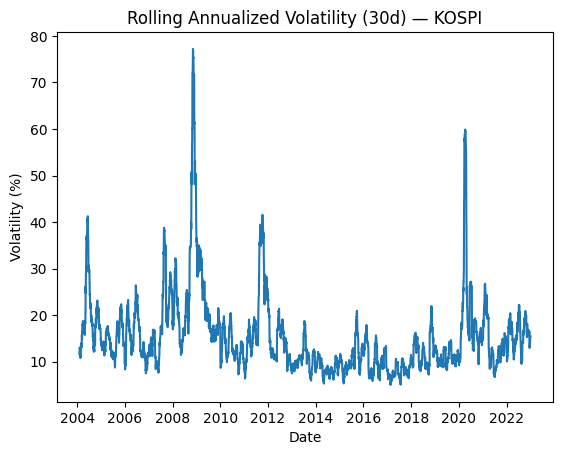

In [13]:
# === Plot: Rolling volatility (TARGET, 30d, annualized) ===
if TARGET in ret.columns:
    rv = ret[TARGET].rolling(30).std() * (252.0**0.5)
    plt.figure()
    plt.plot(rv.index, rv.values)
    plt.title(f"Rolling Annualized Volatility (30d) — {TARGET}")
    plt.xlabel("Date")
    plt.ylabel("Volatility (%)")
    plt.show()
else:
    print(f"TARGET '{TARGET}' not in returns.")


,S&P,DJAI,Nasdaq,VIX,KOSDAQ,FTSE,Nikkei,DAX,CAC,SHCOMP,KOSPI,USD/KRW,US 10Y,Gold,Crude,Brent,Gas
S&P,1.000,0.974,0.950,-0.720,0.219,0.565,0.418,0.599,0.590,0.119,0.288,-0.198,0.326,0.035,0.007,0.026,0.011
DJAI,0.974,1.000,0.893,-0.699,0.207,0.575,0.406,0.604,0.595,0.111,0.280,-0.189,0.345,0.027,0.006,0.021,0.012
Nasdaq,0.950,0.893,1.000,-0.709,0.234,0.503,0.409,0.556,0.540,0.121,0.294,-0.202,0.281,0.035,0.006,0.028,0.015
VIX,-0.720,-0.699,-0.709,1.000,-0.186,-0.429,-0.326,-0.453,-0.465,-0.108,-0.237,0.147,-0.251,-0.045,-0.015,-0.031,0.010
KOSDAQ,0.219,0.207,0.234,-0.186,1.000,0.164,0.486,0.171,0.174,0.252,0.773,-0.198,-0.031,0.066,0.046,0.102,0.030
FTSE,0.565,0.575,0.503,-0.429,0.164,1.000,0.313,0.844,0.890,0.086,0.237,-0.162,0.315,-0.008,-0.024,-0.025,0.009
Nikkei,0.418,0.406,0.409,-0.326,0.486,0.313,1.000,0.346,0.338,0.262,0.604,-0.202,0.124,0.026,0.068,0.124,0.036
DAX,0.599,0.604,0.556,-0.453,0.171,0.844,0.346,1.000,0.928,0.081,0.250,-0.145,0.309,-0.000,-0.021,-0.013,0.018
CAC,0.590,0.595,0.540,-0.465,0.174,0.890,0.338,0.928,1.000,0.084,0.251,-0.159,0.322,0.000,-0.026,-0.022,0.008
SHCOMP,0.119,0.111,0.121,-0.108,0.252,0.086,0.262,0.081,0.084,1.000,0.302,-0.131,0.016,0.039,0.045,0.105,0.006


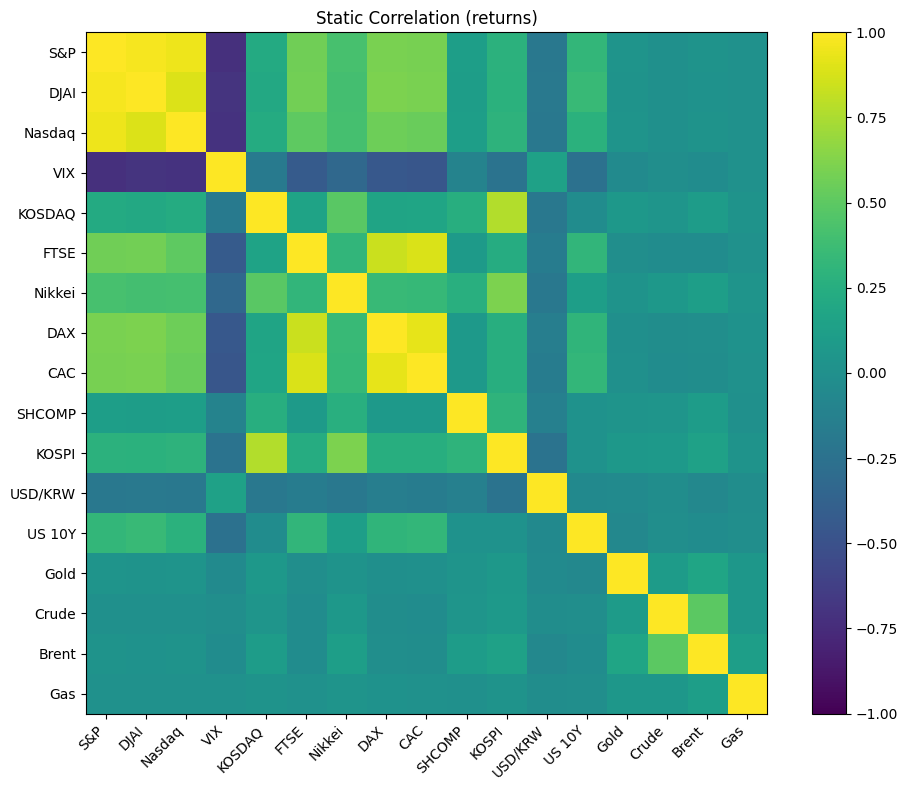

In [14]:
# === Static correlation (returns) ===
corr = ret.corr()
show_df("Static correlation", corr.round(3))

# === Plot: correlation heatmap (imshow) ===
if not corr.empty:
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr.values, vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Static Correlation (returns)")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


In [15]:
# === Rolling correlations for selected pairs ===
PAIRS = [('S&P','KOSPI'),('S&P','Nasdaq'),('KOSPI','KOSDAQ'),('DAX','CAC'),('VIX','S&P'),('Crude','Brent'),('US 10Y','Gold')]

rolling_outputs = {}
for w in ROLL_WINDOWS:
    cols = []
    for a,b in PAIRS:
        if a in ret.columns and b in ret.columns:
            s1,s2 = ret[a].align(ret[b], join='inner')
            rc = s1.rolling(w, min_periods=MIN_PERIODS).corr(s2)
            cols.append(rc.rename(f"{a}__{b}"))
    dfw = pd.concat(cols, axis=1) if cols else pd.DataFrame(index=ret.index)
    rolling_outputs[f"w{w}"] = dfw
    show_df(f"Rolling corr (tail) — w{w}", dfw.tail(10).round(3))


,S&P__KOSPI,S&P__Nasdaq,KOSPI__KOSDAQ,DAX__CAC,VIX__S&P,Crude__Brent,US 10Y__Gold
날짜,,,,,,,
2022-12-21,0.455,0.979,0.847,0.899,-0.537,0.951,0.077
2022-12-22,0.464,0.979,0.849,0.900,-0.547,0.951,0.078
2022-12-23,0.476,0.979,0.854,0.904,-0.555,0.949,0.076
2022-12-24,0.480,0.979,0.854,0.903,-0.552,0.948,0.080
2022-12-26,0.485,0.979,0.844,0.903,-0.552,0.947,0.079
2022-12-27,0.449,0.981,0.828,0.902,-0.541,0.945,0.103
2022-12-28,0.451,0.979,0.830,0.901,-0.551,0.944,0.090
2022-12-29,0.465,0.979,0.837,0.902,-0.555,0.944,0.093
2022-12-30,0.438,0.977,0.832,0.899,-0.565,0.937,0.096


,S&P__KOSPI,S&P__Nasdaq,KOSPI__KOSDAQ,DAX__CAC,VIX__S&P,Crude__Brent,US 10Y__Gold
날짜,,,,,,,
2022-12-21,0.426,0.978,0.886,0.927,-0.680,0.940,0.007
2022-12-22,0.427,0.978,0.888,0.928,-0.679,0.942,0.025
2022-12-23,0.432,0.978,0.890,0.929,-0.680,0.941,0.030
2022-12-24,0.433,0.978,0.890,0.927,-0.677,0.941,0.030
2022-12-26,0.433,0.978,0.891,0.927,-0.677,0.955,0.030
2022-12-27,0.432,0.978,0.890,0.927,-0.681,0.954,0.030
2022-12-28,0.434,0.978,0.887,0.927,-0.681,0.953,0.041
2022-12-29,0.437,0.978,0.888,0.927,-0.677,0.953,0.043
2022-12-30,0.436,0.979,0.888,0.927,-0.679,0.949,0.033


,S&P__KOSPI,S&P__Nasdaq,KOSPI__KOSDAQ,DAX__CAC,VIX__S&P,Crude__Brent,US 10Y__Gold
날짜,,,,,,,
2022-12-21,0.373,0.970,0.884,0.947,-0.761,0.941,-0.002
2022-12-22,0.371,0.971,0.883,0.948,-0.761,0.941,-0.013
2022-12-23,0.374,0.971,0.884,0.948,-0.762,0.940,-0.010
2022-12-24,0.375,0.971,0.884,0.946,-0.762,0.940,-0.009
2022-12-26,0.378,0.971,0.884,0.946,-0.762,0.939,-0.009
2022-12-27,0.374,0.971,0.884,0.946,-0.758,0.939,-0.015
2022-12-28,0.373,0.971,0.883,0.946,-0.760,0.934,0.017
2022-12-29,0.365,0.970,0.882,0.937,-0.758,0.934,0.013
2022-12-30,0.364,0.970,0.884,0.935,-0.761,0.933,0.017


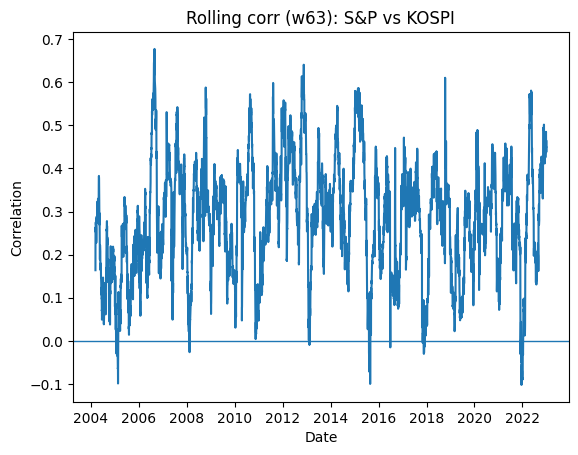

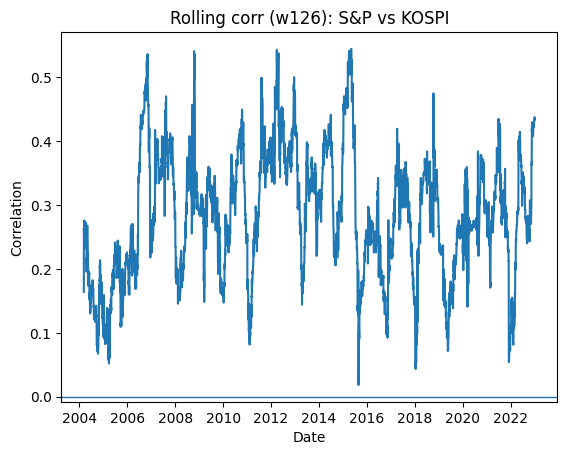

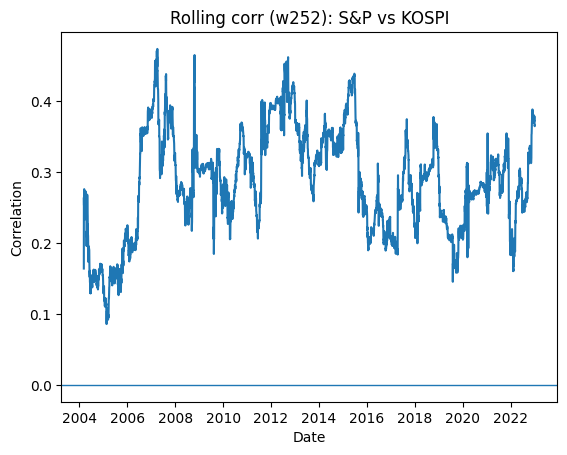

In [16]:

# === Plot: First rolling correlation series for each window ===
for w, dfw in rolling_outputs.items():
    if dfw.shape[1] > 0:
        col = dfw.columns[0]
        plt.figure()
        plt.plot(dfw.index, dfw[col].values)
        plt.axhline(0, lw=1)
        plt.title(f"Rolling corr ({w}): {col.replace('__',' vs ')}")
        plt.xlabel("Date")
        plt.ylabel("Correlation")
        plt.show()


In [17]:

# === Extreme events (generic) ===
events = []
for col in ret.columns:
    r = ret[col].dropna()
    if len(r) < 100:
        continue
    lo, hi = r.quantile(EXTREME_P_LO), r.quantile(EXTREME_P_HI)
    sub = r[(r <= lo) | (r >= hi)]
    for dt, val in sub.items():
        events.append({'Date': dt, 'Asset': col, 'Return_%': float(val), 'Abs_Return_%': float(abs(val))})
ext_df = pd.DataFrame(events)
if not ext_df.empty:
    top_ext = ext_df.sort_values('Abs_Return_%', ascending=False).head(TOP_EXTREMES)
    top_ext['Year'] = top_ext['Date'].dt.year
    top_ext['Weekday'] = top_ext['Date'].dt.day_name()
else:
    top_ext = pd.DataFrame()
show_df("Extreme events (Top N)", top_ext)


,Date,Asset,Return_%,Abs_Return_%,Year,Weekday
1770,2020-04-20,Crude,-305.966065,305.966065,2020,Monday
1771,2020-04-21,Crude,-126.601116,126.601116,2020,Tuesday
437,2018-02-06,VIX,115.597925,115.597925,2018,Tuesday
363,2007-02-28,VIX,64.215247,64.215247,2007,Wednesday
468,2021-01-28,VIX,61.642043,61.642043,2021,Thursday
476,2021-11-27,VIX,54.036604,54.036604,2021,Saturday
393,2011-08-09,VIX,50.000000,50.000000,2011,Tuesday
1490,2020-03-11,US 10Y,49.899801,49.899801,2020,Wednesday
423,2016-06-25,VIX,49.333335,49.333335,2016,Saturday
465,2020-06-12,VIX,47.950676,47.950676,2020,Friday


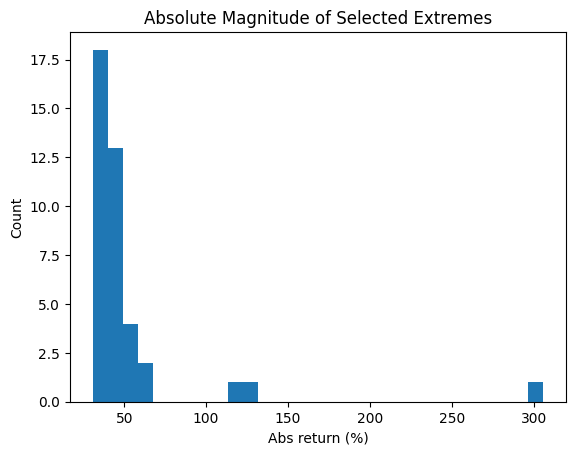

In [18]:

# === Plot: Distribution of absolute extreme magnitudes ===
if not top_ext.empty:
    plt.figure()
    plt.hist(top_ext['Abs_Return_%'].values, bins=30)
    plt.title("Absolute Magnitude of Selected Extremes")
    plt.xlabel("Abs return (%)")
    plt.ylabel("Count")
    plt.show()
else:
    print("No extremes selected.")


,Date,VIX_Return_%,VIX_Level,S&P_Return_%,KOSPI_Return_%,Nasdaq_Return_%,DAX_Return_%,Nikkei_Return_%,Weekday
77,2018-02-06,115.597925,37.320000,-4.097922,-1.542689,-3.776029,-0.763932,-4.725492,Tuesday
3,2007-02-28,64.215247,18.309999,-3.472540,-2.561530,-3.859419,-2.958908,-2.846595,Wednesday
108,2021-01-28,61.642043,37.209999,-2.567788,-1.713658,-2.608678,-1.806146,-1.528856,Thursday
116,2021-11-27,54.036604,28.620001,-2.272482,0.000000,-2.231399,-4.152163,0.000000,Saturday
33,2011-08-09,50.000000,48.000000,-6.663446,-3.642781,-6.899356,-5.017352,-1.682639,Tuesday
63,2016-06-25,49.333335,25.760000,-3.591980,0.000000,-4.115243,-6.823321,0.000000,Saturday
105,2020-06-12,47.950676,40.790001,-5.894406,-2.043384,-5.265476,-4.468180,-0.745029,Friday
98,2020-02-25,46.545672,25.030001,-3.351363,1.181799,-3.710189,-4.006750,-3.340911,Tuesday
55,2015-08-22,46.447239,28.030001,-3.185097,0.000000,-3.515131,-2.949245,0.000000,Saturday
70,2017-05-18,46.384983,15.590000,-1.817821,-0.272996,-2.571041,-1.350459,-1.317300,Thursday


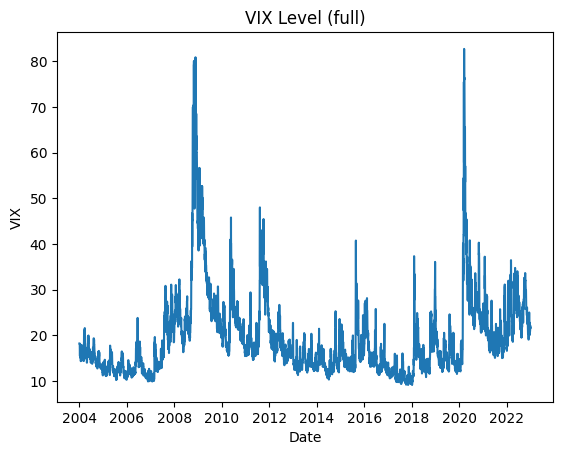

In [19]:

# === VIX extremes with concurrent equity returns ===
if 'VIX' in df.columns:
    vix = df['VIX'].dropna()
    vix_ret = vix.pct_change().mul(100.0).dropna()
    lo, hi = vix_ret.quantile(EXTREME_P_LO), vix_ret.quantile(EXTREME_P_HI)
    sub = vix_ret[(vix_ret <= lo) | (vix_ret >= hi)]
    rows = []
    equities = ['S&P','KOSPI','Nasdaq','DAX','Nikkei']
    for dt, val in sub.items():
        row = {'Date': dt, 'VIX_Return_%': float(val), 'VIX_Level': float(vix.loc[dt])}
        for eq in equities:
            if eq in df.columns:
                try:
                    row[f"{eq}_Return_%"] = float(df[eq].pct_change().loc[dt] * 100.0)
                except Exception:
                    row[f"{eq}_Return_%"] = np.nan
        rows.append(row)
    vix_ext = pd.DataFrame(rows).sort_values(by='VIX_Return_%', key=np.abs, ascending=False).head(TOP_EXTREMES)
    vix_ext['Weekday'] = vix_ext['Date'].dt.day_name()
    show_df("VIX extremes (Top N)", vix_ext)

    # Plot VIX level at extremes
    if not vix_ext.empty:
        plt.figure()
        plt.plot(vix.index, vix.values)
        plt.title("VIX Level (full)")
        plt.xlabel("Date")
        plt.ylabel("VIX")
        plt.show()
else:
    print("VIX column not found — skipping VIX extremes.")


In [20]:

# === Tail summary & contagion ===
tail_rows = []
for col in ret.columns:
    r = ret[col].dropna()
    if len(r) < 100: 
        continue
    var99, es99 = hist_var_es(r, 0.01)
    tail_ratio = (abs(r.quantile(0.01)) / (r.quantile(0.99) if r.quantile(0.99) > 0 else np.nan))
    extreme_thr = 2 * r.std()
    pos_ratio = (r > extreme_thr).mean() * 100.0
    neg_ratio = (r < -extreme_thr).mean() * 100.0
    # longest runs
    def longest_run(mask):
        m = mask.values.astype(int)
        best = cur = 0
        for v in m:
            if v:
                cur += 1
                best = max(best, cur)
            else:
                cur = 0
        return best
    tail_rows.append({
        'Asset': col,
        'VaR_99_%': var99, 'ES_99_%': es99,
        'Tail_Ratio': tail_ratio,
        'Max_Daily_Loss_%': r.min(), 'Max_Daily_Gain_%': r.max(),
        'Extreme_Pos_Ratio_%': pos_ratio, 'Extreme_Neg_Ratio_%': neg_ratio,
        'Max_Consec_Pos': longest_run(r > extreme_thr),
        'Max_Consec_Neg': longest_run(r < -extreme_thr),
    })
tail_tbl = pd.DataFrame(tail_rows).set_index('Asset').sort_index()
show_df("Tail summary", tail_tbl.round(3))

# Contagion (same-day multi-asset extremes)
sigmas = ret.std()
rows = []
for dt, row in ret.iterrows():
    extreme_assets = [c for c in ret.columns if c in row.index and not pd.isna(row[c]) and abs(row[c]) > CONTAGION_SIGMA * sigmas[c]]
    if len(extreme_assets) >= 2:
        rows.append({'Date': dt, 'Count': len(extreme_assets), 'Assets': ','.join(extreme_assets[:10])})
contagion_tbl = pd.DataFrame(rows)
show_df("Contagion events", contagion_tbl)


,VaR_99_%,ES_99_%,Tail_Ratio,Max_Daily_Loss_%,Max_Daily_Gain_%,Extreme_Pos_Ratio_%,Extreme_Neg_Ratio_%,Max_Consec_Pos,Max_Consec_Neg
Asset,,,,,,,,,
Brent,6.007,8.378,1.100,-24.404,21.019,2.623,2.740,3,3
CAC,3.634,4.986,1.117,-12.277,11.176,2.270,2.875,3,3
Crude,6.520,16.160,1.035,-305.966,37.662,0.370,0.269,2,2
DAX,3.456,4.860,1.098,-12.239,11.402,2.522,2.841,2,3
DJAI,3.109,4.629,1.104,-12.927,11.365,2.186,2.724,3,2
FTSE,3.056,4.283,1.111,-10.874,9.839,2.337,2.909,3,3
Gas,7.963,10.432,0.834,-25.954,46.481,3.009,2.371,2,2
Gold,3.023,3.998,1.122,-9.354,9.028,2.589,2.993,2,3
KOSDAQ,4.319,6.115,1.324,-11.706,11.469,1.883,3.245,2,3


,Date,Count,Assets
0,2004-01-15,2,"Gold,Gas"
1,2004-02-25,2,"USD/KRW,Gold"
2,2004-03-12,5,"KOSDAQ,FTSE,DAX,CAC,KOSPI"
3,2004-03-16,2,"VIX,DAX"
4,2004-04-29,3,"KOSDAQ,KOSPI,USD/KRW"
...,...,...,...
998,2022-12-01,5,"S&P,DJAI,Nasdaq,USD/KRW,Gold"
999,2022-12-02,2,"USD/KRW,Gas"
1000,2022-12-16,6,"S&P,DJAI,Nasdaq,DAX,CAC,USD/KRW"
1001,2022-12-28,2,"KOSPI,Gas"
